# Import Dependencies

In [13]:
# Import Basic Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, KFold

# Import Modeling Dependencies
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
# Dataset Preparation
# df1 = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe.csv")
df2 = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe_drop_multico.csv")

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\randi\AppData\Local\Temp\ipykernel_19288\1578260001.py:3: SyntaxWarning: invalid escape sequence '\P'
  df2 = pd.read_csv("D:\ProjectDS\Californian_Housing_Pred\data\california_housing_train_fe_drop_multico.csv")


# Modeling DataFrame1 (Original Data + Feature Engineering)

In [3]:
# df1.head()

In [4]:
df2.head()

,longitude,latitude,housing_median_age,population,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-114.31,34.19,15,1015,1.4936,66900,11.889831,0.228617,2.150424
1,-114.47,34.40,19,1129,1.8200,80100,16.522678,0.248497,2.438445
2,-114.56,33.69,17,333,1.6509,85700,6.153846,0.241667,2.846154
3,-114.57,33.64,14,515,3.1917,73400,6.641593,0.224517,2.278761
4,-114.57,33.57,20,624,1.9250,65500,5.549618,0.224209,2.381679


In [5]:
# Separate Features and Target Variable
# X1 = df1.drop(columns=['median_house_value'])
# y1 = df1['median_house_value']
X2 = df2.drop(columns=['median_house_value'])
y2 = df2['median_house_value']

In [6]:
# Data Splitting
# X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [7]:
# Modeling
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "AdaBoost": AdaBoostRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42,
        n_estimators=200,
        verbosity=0
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0
    )
}

In [8]:
# Model Benchmarking
results = []

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():

    scores = cross_validate(
        model,
        X2,
        y2,
        cv=cv,
        scoring=[
            "r2",
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error"
        ],
        n_jobs=-1
    )

    results.append({
        "Model": name,
        "R2": scores["test_r2"].mean(),
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "RMSE": -scores["test_neg_root_mean_squared_error"].mean()
    })

results_df = pd.DataFrame(results)

In [9]:
# Re-arrange models
results_df = results_df.sort_values(
    by="R2",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,R2,MAE,RMSE
0,CatBoost,0.854344,29233.015345,44245.607132
1,LightGBM,0.841436,30925.874572,46163.956937
2,XGBoost,0.837955,30924.656821,46676.313643
3,Random Forest,0.810100,33129.116666,50519.288605
4,Extra Trees,0.808374,33584.969129,50751.370231
5,Gradient Boosting,0.789379,36874.097152,53205.640463
6,Decision Tree,0.621881,45595.008471,71261.850196
7,Linear Regression,0.485772,52256.108417,80752.893825
8,Lasso,0.485760,52257.117713,80753.594981
9,Ridge,0.485124,52284.764816,80790.599056


# Modeling DataFrame2 (Feature Engineering)

In [10]:
# # Model Benchmarking
# results2 = []

# for name, model in models.items():

#     scores = cross_validate(
#         model,
#         X2,
#         y2,
#         cv=cv,
#         scoring=[
#             "r2",
#             "neg_mean_absolute_error",
#             "neg_root_mean_squared_error"
#         ],
#         n_jobs=-1
#     )

#     results2.append({
#         "Model": name,
#         "R2": scores["test_r2"].mean(),
#         "MAE": -scores["test_neg_mean_absolute_error"].mean(),
#         "RMSE": -scores["test_neg_root_mean_squared_error"].mean()
#     })

# results_df2 = pd.DataFrame(results2)

In [11]:
# # Re-arrange models
# results_df2 = results_df2.sort_values(
#     by="R2",
#     ascending=False
# )

# results_df2.reset_index(drop=True, inplace=True)

# results_df2

,Model,R2,MAE,RMSE
0,CatBoost,0.854344,29233.015345,44245.607132
1,LightGBM,0.841436,30925.874572,46163.956937
2,XGBoost,0.837955,30924.656821,46676.313643
3,Random Forest,0.810100,33129.116666,50519.288605
4,Extra Trees,0.808374,33584.969129,50751.370231
5,Gradient Boosting,0.789379,36874.097152,53205.640463
6,Decision Tree,0.621881,45595.008471,71261.850196
7,Linear Regression,0.485772,52256.108417,80752.893825
8,Lasso,0.485760,52257.117713,80753.594981
9,Ridge,0.485124,52284.764816,80790.599056


## Data 1
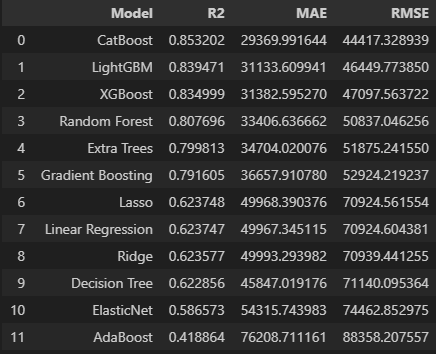

## Data 2
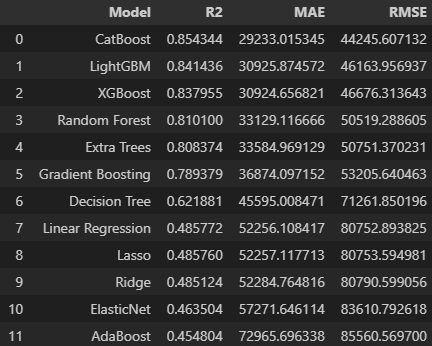

Penghapusan fitur yang memiliki multikolinearitas tinggi menghasilkan perubahan performa yang sangat kecil pada model berbasis ensemble tree seperti CatBoost, LightGBM, dan Random Forest. Hal ini menunjukkan bahwa model-model tersebut relatif robust terhadap multikolinearitas. Sebaliknya, performa model linear mengalami penurunan yang cukup signifikan setelah penghapusan fitur, yang mengindikasikan bahwa fitur-fitur tersebut masih berkontribusi terhadap kemampuan prediksi model linear.
Berdasarkan percobaan terhadap beberapa mdoel tersebut, dapat ditentukan bahwa model CatBoost akan dipilih sebagai model utama dimana dengan menggunakan data penghapusan fitur redudan namun menggunakan feature engineering

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Model sudah tersimpan di file 'catboost_best_model.cbm'
# Untuk memuat dan menggunakan model yang sudah disimpan:

loaded_model.fit(X_train2, y_train2, verbose=0)

# Membuat prediksi menggunakan loaded model
y_pred = loaded_model.predict(X_test2)

# Mengevaluasi performa

r2 = r2_score(y_test2, y_pred)
mae = mean_absolute_error(y_test2, y_pred)
rmse = np.sqrt(mean_squared_error(y_test2, y_pred))

print(f"R2 Score: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

In [18]:
# Fit (if not already fitted) and save the best CatBoost model
model.fit(X_train2, y_train2, verbose=0)
model.save_model('catboost_best_model.cbm')

# Example: load saved model
loaded_model = CatBoostRegressor()
loaded_model.load_model('catboost_best_model.cbm')

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0)